**PROBLEM**

Na tapet bierzemy stochastyczne równanie różniczkowe postaci:
$$
\begin{cases}
dX_t = a(t, X_t)dt + b(t, X_t)dW_t \\
X_0 = x_0
\end{cases}.
$$
**SCHEMAT EULERA-MARUYAMY**

Zaczniemy od metody Eulera-Maruyamy, która zwraca ciąg aproksymacji $\{Y_n\}_{n=0}^{N}$ w punktach $0=t_0<\dots <t_N = T,$ gdzie:
$$
\begin{cases}
Y_0 = x_0 \\
Y_{n+1} = Y_n + a(t_n, Y_n) \Delta t_n + b(t_n, Y_n) \Delta W_n
\end{cases},
$$
gdzie $\Delta t_n = t_{n+1} - t_n ,$ natomiast $\Delta W_n = W_{n+1} - W_n ,\space n = 0,\dots , N-1.$

In [3]:
import numpy as np
from matplotlib import pyplot as plt

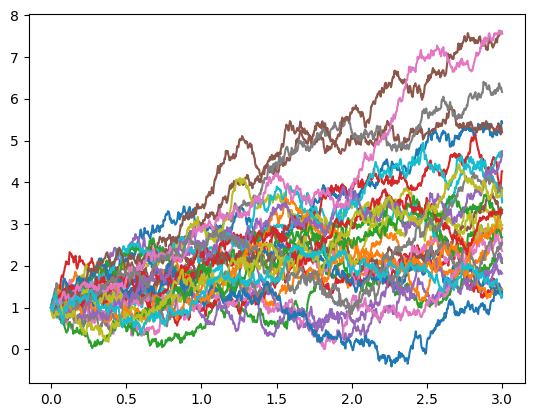

In [ ]:
def eulerMaruyama(x0, T, a, b, N):
    h = T/(N-1) # długość kroku
    t = np.linspace(0, T, N) # podział czasu
    deltat = t[1:] - t[:-1] # przyrosty czasu

    # W to biały szum
    W = np.zeros(N)
    W[1:] = np.sqrt(h)*np.random.randn(N-1) # symulowanie procesu Wienera
    W = np.cumsum(W)
    deltaW = W[1:] - W[:-1] # przyrosty szumu

    # Y to nasz ciąg aproksymacji
    Y = x0 * np.ones(N)
    for k in range(N-1):
        Y[k+1] = Y[k] + a(t[k], Y[k])*deltat[k] + b(t[k], Y[k])*deltaW[k]
    return t, Y

# przykładowa realizacja
a = lambda t, X: 1
b = lambda t, X: 1
N = 1000
x0 = 1
T = 3
for i in range(30):
    plt.plot(eulerMaruyama(x0, T, a, b, N)[0], eulerMaruyama(x0, T, a, b, N)[1])
plt.show()

**POSKROMIONY SCHEMAT EULERA**

Teraz przedstawimy poskromiony schemat Eulera. Tworzymy ciąg procesów według wzoru:

$$
\begin{cases}
dX_{n+1} (t) = a_n \Big( t, X_n \big( \kappa _n (t)\big) \Big) dt + b\Big( t, X_n \big( \kappa _n (t)\big) \Big) dW(t) \\
dX_{n} (0) = X(t) 
\end{cases},
$$
gdzie
$$ \kappa _n (t) = \frac{\lfloor nt \rfloor}{n}, $$
oraz
$$
b_n (t, x) = \frac{b(t, x)}{1 + n^{-\alpha}|b(t, x)|}. 
$$
